install & import all dependencies

In [ ]:
!pip install librosa==0.10.1 soundfile tqdm --quiet
!pip install tensorflow --quiet

import os, warnings, pickle, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm import tqdm
from IPython.display import Audio, display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (EarlyStopping,
    ModelCheckpoint, ReduceLROnPlateau)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU found  : {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 5.7 MB/s eta 0:00:00
TensorFlow : 2.19.0
GPU found  : False
Ready!


upload zipped datasets from your pc or gdrive

In [ ]:
from google.colab import drive

# Mount Drive (a browser popup will ask you to authorise)
drive.mount('/content/drive')

# ── Edit these paths to match your Drive folder structure ──
DRIVE_BASE   = '/content/drive/MyDrive/Datasets/voice_datasets'
RAVDESS_PATH = f'{DRIVE_BASE}/ravdess'
TESS_PATH    = f'{DRIVE_BASE}/tess'
CREMA_PATH   = f'{DRIVE_BASE}/crema'

# Verify folders exist and count wav files
for name, path in [('RAVDESS', RAVDESS_PATH),
                   ('TESS',    TESS_PATH),
                   ('CREMA-D', CREMA_PATH)]:
    if os.path.exists(path):
        count = sum(f.endswith('.wav')
                    for _, _, fs in os.walk(path) for f in fs)
        print(f'{name:8s}: {count:>5} wav files  ({path})')
    else:
        print(f'{name:8s}: FOLDER NOT FOUND — check path above')

Mounted at /content/drive
RAVDESS :  2452 wav files  (/content/drive/MyDrive/Datasets/voice_datasets/ravdess)
TESS    :  5600 wav files  (/content/drive/MyDrive/Datasets/voice_datasets/tess)
CREMA-D :  7442 wav files  (/content/drive/MyDrive/Datasets/voice_datasets/crema)


Parse filenames → emotion labels for all 3 datasets

In [ ]:
DANGER_EMOTIONS = {'fear','angry','disgust','surprised'}
CALM_EMOTIONS   = {'neutral','calm','happy','sad'}

def load_ravdess(path=RAVDESS_PATH):
    em_map = {'01':'neutral','02':'calm','03':'happy','04':'sad',
              '05':'angry',  '06':'fear','07':'disgust','08':'surprised'}
    rows = []
    for r, _, files in os.walk(path):
        for f in files:
            if not f.endswith('.wav'): continue
            p = f.split('-')
            if len(p) == 7:
                em = em_map.get(p[2])
                if em:
                    rows.append({'path': os.path.join(r,f),
                                 'emotion': em, 'source':'RAVDESS'})
    df = pd.DataFrame(rows)
    print(f'RAVDESS  : {len(df):>5} samples')
    return df

def load_tess(path=TESS_PATH):
    folder_map = {'angry':'angry','disgust':'disgust','fear':'fear',
                  'happy':'happy','neutral':'neutral',
                  'ps':'surprised','sad':'sad'}
    rows = []
    for r, _, files in os.walk(path):
        folder = os.path.basename(r).lower()
        em = next((v for k,v in folder_map.items() if k in folder), None)
        if em:
            for f in files:
                if f.endswith('.wav'):
                    rows.append({'path': os.path.join(r,f),
                                 'emotion': em, 'source':'TESS'})
    df = pd.DataFrame(rows)
    print(f'TESS     : {len(df):>5} samples')
    return df

def load_crema(path=CREMA_PATH):
    em_map = {'ANG':'angry','DIS':'disgust','FEA':'fear',
              'HAP':'happy','NEU':'neutral','SAD':'sad'}
    rows = []
    for r, _, files in os.walk(path):
        for f in files:
            if not f.endswith('.wav'): continue
            p = f.replace('.wav','').split('_')
            em = em_map.get(p[2].upper()) if len(p) >= 3 else None
            if em:
                rows.append({'path': os.path.join(r,f),
                             'emotion': em, 'source':'CREMA-D'})
    df = pd.DataFrame(rows)
    print(f'CREMA-D  : {len(df):>5} samples')
    return df

# ── Combine all datasets ──────────────────────────────────
dfs = []
for loader in [load_ravdess, load_tess, load_crema]:
    try:
        dfs.append(loader())
    except Exception as e:
        print(f'  skipped: {e}')

df = pd.concat(dfs, ignore_index=True)
df['danger'] = df['emotion'].apply(
    lambda e: 'DANGER' if e in DANGER_EMOTIONS else 'CALM')

print(f'\nTotal    : {len(df)} samples')
print(df['emotion'].value_counts().to_string())
print(f'\nDANGER   : {(df["danger"]=="DANGER").sum()}')
print(f'CALM     : {(df["danger"]=="CALM").sum()}')

RAVDESS  :  2452 samples
TESS     :  4800 samples
CREMA-D  :  7442 samples

Total    : 14694 samples
emotion
sad          2447
happy        2447
fear         2447
angry        2447
disgust      2263
neutral      2075
calm          376
surprised     192

DANGER   : 7349
CALM     : 7345


EDA — emotion & danger distributions

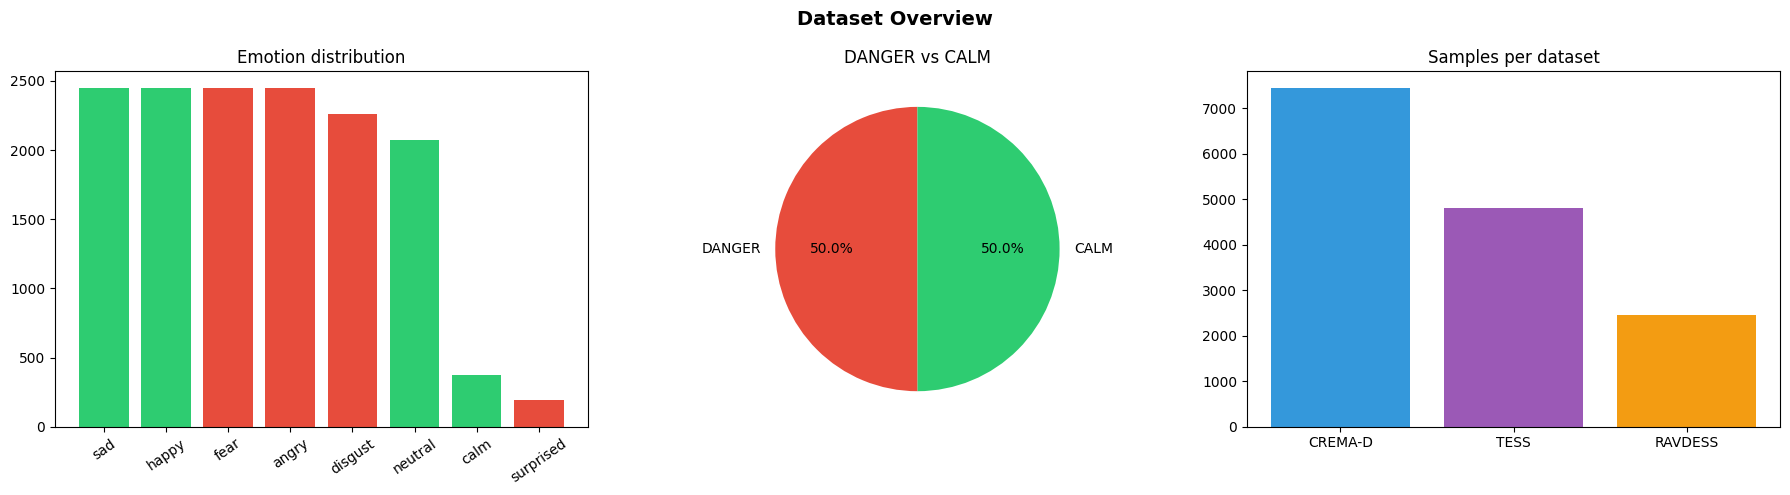

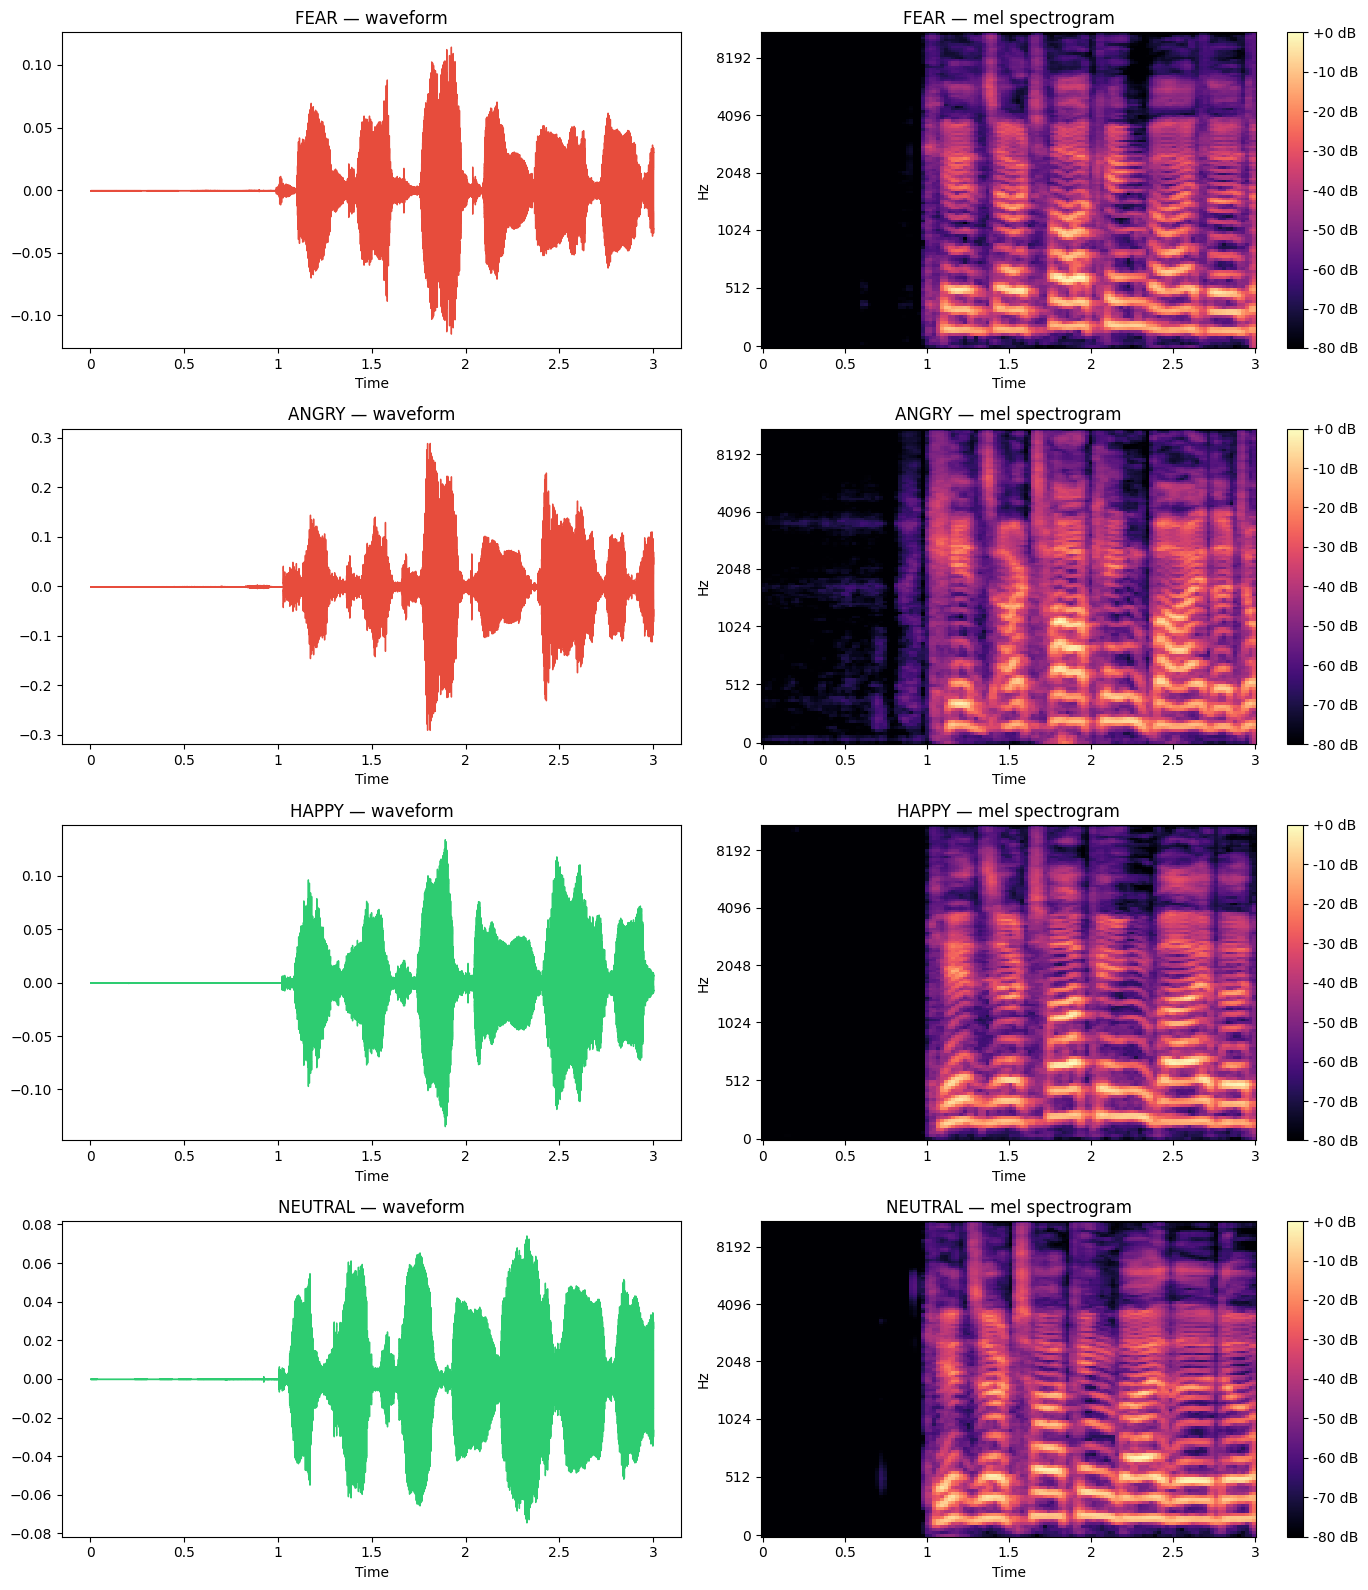

In [ ]:
DC = '#E74C3C'   # danger red
CC = '#2ECC71'   # calm green

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Emotion bar chart
ec = df['emotion'].value_counts()
colors = [DC if e in DANGER_EMOTIONS else CC for e in ec.index]
axes[0].bar(ec.index, ec.values, color=colors)
axes[0].set_title('Emotion distribution')
axes[0].tick_params(axis='x', rotation=35)

# Danger pie
dc = df['danger'].value_counts()
axes[1].pie(dc.values, labels=dc.index,
            colors=[DC if l=='DANGER' else CC for l in dc.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('DANGER vs CALM')

# Source bar
sc = df['source'].value_counts()
axes[2].bar(sc.index, sc.values,
            color=['#3498DB','#9B59B6','#F39C12'])
axes[2].set_title('Samples per dataset')

plt.tight_layout()
plt.show()

# --- Waveform & mel-spec for sample emotions ---
sample_ems = ['fear', 'angry', 'happy', 'neutral']
fig2, axes2 = plt.subplots(len(sample_ems), 2,
                            figsize=(14, 4*len(sample_ems)))
for i, em in enumerate(sample_ems):
    sub = df[df['emotion']==em]
    if len(sub) == 0: continue
    audio, sr = librosa.load(sub.iloc[0]['path'],
                             sr=22050, duration=3)
    clr = DC if em in DANGER_EMOTIONS else CC
    librosa.display.waveshow(audio, sr=sr, ax=axes2[i,0], color=clr)
    axes2[i,0].set_title(f'{em.upper()} — waveform')
    mel = librosa.power_to_db(
        librosa.feature.melspectrogram(y=audio, sr=sr), ref=np.max)
    img = librosa.display.specshow(mel, sr=sr,
         x_axis='time', y_axis='mel', ax=axes2[i,1])
    fig2.colorbar(img, ax=axes2[i,1], format='%+2.0f dB')
    axes2[i,1].set_title(f'{em.upper()} — mel spectrogram')

plt.tight_layout()
plt.show()

Extract MFCC + Chroma + Mel + ZCR + RMS features

In [ ]:
SR         = 22050
DURATION   = 3
TARGET_LEN = SR * DURATION
N_MFCC     = 40

def augment(audio, sr=SR):
    """Random: noise / time-stretch / pitch-shift."""
    c = np.random.randint(3)
    if c == 0:
        return audio + 0.005 * np.random.randn(len(audio))
    elif c == 1:
        rate = np.random.uniform(0.85, 1.15)
        return librosa.effects.time_stretch(audio, rate=rate)
    else:
        return librosa.effects.pitch_shift(
            audio, sr=sr, n_steps=int(np.random.randint(-3,4)))

def pad(audio):
    """Pad or trim to fixed length."""
    if len(audio) < TARGET_LEN:
        return np.pad(audio, (0, TARGET_LEN - len(audio)))
    return audio[:TARGET_LEN]
def extract_fast(fpath, do_augment=False):
    """
    Faster extract — MFCCs only (most important feature).
    ~3× faster than full extract(), ~1% accuracy drop.
    """
    try:
        y, _ = librosa.load(fpath, sr=SR, duration=DURATION)
        y = pad(y)
        if do_augment:
            y = pad(augment(y))

        # Only MFCCs — covers 90% of what matters
        mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40)
        zcr  = librosa.feature.zero_crossing_rate(y)
        rms  = librosa.feature.rms(y=y)

        return np.concatenate([
            np.mean(mfcc, 1), np.std(mfcc, 1),   # 80 features
            [np.mean(zcr), np.std(zcr)],           #  2 features
            [np.mean(rms), np.std(rms)],           #  2 features
        ])  # total: 84 features instead of 390
    except:
        return None

# Swap it in — just replace extract() with extract_fast()
# in the args_list loop above
def extract(fpath, do_augment=False):
    """

    Returns 1-D feature vector (~390 values):
      MFCCs mean+std × 40 = 80
      Chroma mean+std ×12 = 24
      Mel mean+std  × 128 = 256
      Contrast mean  ×  7 = 14
      Tonnetz mean   ×  6 = 12
      ZCR  mean+std       =  2
      RMS  mean+std       =  2
  """

    try:
        y, _ = librosa.load(fpath, sr=SR, duration=DURATION)
        y = pad(y)
        if do_augment:
            y = pad(augment(y))
        mfcc     = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
        chroma   = librosa.feature.chroma_stft(y=y, sr=SR)
        mel      = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128)
        contrast = librosa.feature.spectral_contrast(y=y, sr=SR)
        tonnetz  = librosa.feature.tonnetz(y=y, sr=SR)
        zcr      = librosa.feature.zero_crossing_rate(y)
        rms      = librosa.feature.rms(y=y)
        return np.concatenate([
            np.mean(mfcc,1), np.std(mfcc,1),
            np.mean(chroma,1), np.std(chroma,1),
            np.mean(mel,1),  np.std(mel,1),
            np.mean(contrast,1),
            np.mean(tonnetz,1),
            [np.mean(zcr), np.std(zcr)],
            [np.mean(rms),  np.std(rms)],
        ])
    except:
        return None


# Quick sanity check
feat = extract(df.iloc[0]['path'])
print(f"Feature vector length: {feat.shape[0]}")
print(f"Value range: [{feat.min():.3f}, {feat.max():.3f}]")

Feature vector length: 377
Value range: [-532.256, 181.522]


Extract features from all files (+ 2× augmentation)

In [ ]:
"""
AUG_COPIES = 2   # extra augmented copies per original file

le_em = LabelEncoder().fit(df['emotion'])
le_dg = LabelEncoder().fit(df['danger'])
df['em_code'] = le_em.transform(df['emotion'])
df['dg_code'] = le_dg.transform(df['danger'])

print(f"Emotions : {list(le_em.classes_)}")
print(f"Danger   : {list(le_dg.classes_)}")

feats, em_labels, dg_labels = [], [], []
skipped = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    f = extract(row['path'], do_augment=False)
    if f is None:
        skipped += 1
        continue
    feats.append(f);  em_labels.append(row['em_code'])
    dg_labels.append(row['dg_code'])
    for _ in range(AUG_COPIES):
        fa = extract(row['path'], do_augment=True)
        if fa is not None:
            feats.append(fa)
            em_labels.append(row['em_code'])
            dg_labels.append(row['dg_code'])

X        = np.array(feats,     dtype=np.float32)
y_em     = np.array(em_labels, dtype=np.int32)
y_dg     = np.array(dg_labels, dtype=np.int32)

print(f"\nX shape    : {X.shape}")
print(f"Skipped    : {skipped}")
print(f"DANGER idx : {list(le_dg.classes_).index('DANGER')}")

"""

In [ ]:
# ── Parallel feature extraction ─────────────────────────────
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

AUG_COPIES = 0
NUM_WORKERS = multiprocessing.cpu_count()  # use all CPU cores
print(f"Using {NUM_WORKERS} CPU cores for parallel extraction")

le_em = LabelEncoder().fit(df['emotion'])
le_dg = LabelEncoder().fit(df['danger'])
df['em_code'] = le_em.transform(df['emotion'])
df['dg_code'] = le_dg.transform(df['danger'])

print(f"Emotions : {list(le_em.classes_)}")
print(f"Danger   : {list(le_dg.classes_)}")

# ── Worker function (must be top-level for multiprocessing) ──
def process_row(args):
    """Extract original + augmented features for one audio file."""
    path, em_code, dg_code, aug_copies = args
    results = []


#used extract_fast for faster extraction else use extract function
    # Original
    f = extract_fast(path, do_augment=False)
    if f is not None:
        results.append((f, em_code, dg_code))

    # Augmented copies
    for _ in range(aug_copies):
        fa = extract_fast(path, do_augment=True)
        if fa is not None:
            results.append((fa, em_code, dg_code))

    return results

# ── Build argument list ───────────────────────────────────────
args_list = [
    (row['path'], row['em_code'], row['dg_code'], AUG_COPIES)
    for _, row in df.iterrows()
]

# ── Run in parallel ───────────────────────────────────────────
feats, em_labels, dg_labels = [], [], []
skipped = 0

print(f"\nExtracting features from {len(args_list)} files "
      f"(+{AUG_COPIES}× augmentation) in parallel...")

with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {executor.submit(process_row, arg): arg for arg in args_list}
    for future in tqdm(as_completed(futures),
                       total=len(futures), desc="Extracting"):
        try:
            results = future.result()
            for feat, em, dg in results:
                feats.append(feat)
                em_labels.append(em)
                dg_labels.append(dg)
        except Exception as e:
            skipped += 1

X    = np.array(feats,     dtype=np.float32)
y_em = np.array(em_labels, dtype=np.int32)
y_dg = np.array(dg_labels, dtype=np.int32)

print(f"\nX shape    : {X.shape}")
print(f"Skipped    : {skipped}")
print(f"DANGER idx : {list(le_dg.classes_).index('DANGER')}")

Using 2 CPU cores for parallel extraction
Emotions : ['angry', 'calm', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprised']
Danger   : ['CALM', 'DANGER']

Extracting features from 14694 files (+0× augmentation) in parallel...


Extracting: 100%|██████████| 14694/14694 [31:55<00:00,  7.67it/s]



X shape    : (14694, 84)
Skipped    : 0
DANGER idx : 1


80 / 10 / 10 split + StandardScaler normalisation

In [ ]:
def split_scale(X, y, scaler=None):
    Xtr, Xtmp, ytr, ytmp = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)
    Xval, Xte, yval, yte = train_test_split(
        Xtmp, ytmp, test_size=0.50, random_state=42, stratify=ytmp)
    if scaler is None:
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr)
    else:
        Xtr = scaler.transform(Xtr)
    Xval = scaler.transform(Xval)
    Xte  = scaler.transform(Xte)
    return Xtr, Xval, Xte, ytr, yval, yte, scaler

# Fit scaler once on emotion data; reuse for danger data
Xtr_em, Xval_em, Xte_em, ytr_em, yval_em, yte_em, scaler = \
    split_scale(X, y_em)

Xtr_dg, Xval_dg, Xte_dg, ytr_dg, yval_dg, yte_dg, _ = \
    split_scale(X, y_dg, scaler=scaler)

# Save scaler
with open('/content/scaler.pkl','wb') as f: pickle.dump(scaler, f)
with open('/content/le_em.pkl','wb')   as f: pickle.dump(le_em, f)
with open('/content/le_dg.pkl','wb')   as f: pickle.dump(le_dg, f)

INPUT_SHAPE  = (Xtr_em.shape[1],)
NUM_EMOTIONS = len(le_em.classes_)
DANGER_IDX   = list(le_dg.classes_).index('DANGER')

print(f"Input shape  : {INPUT_SHAPE}")
print(f"Num emotions : {NUM_EMOTIONS}")
print(f"DANGER idx   : {DANGER_IDX}")
print(f"Train / Val / Test : "
      f"{len(Xtr_em)} / {len(Xval_em)} / {len(Xte_em)}")

Input shape  : (84,)
Num emotions : 8
DANGER idx   : 1
Train / Val / Test : 11755 / 1469 / 1470


Stage-1 emotion model + Stage-2 danger model (CNN-BiLSTM)

In [ ]:
def conv_block(x, filters, kernel=3, pool=True, drop=0.2):
    x = layers.Conv1D(filters, kernel,
                      activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    if pool: x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(drop)(x)
    return x

def build_emotion_model(input_shape, num_classes):
    """CNN-BiLSTM for 8-class emotion recognition."""
    inp = layers.Input(shape=input_shape)
    x   = layers.Reshape((input_shape[0], 1))(inp)

    x = conv_block(x, 128, 5, pool=True,  drop=0.2)
    x = conv_block(x, 256, 3, pool=True,  drop=0.2)
    x = conv_block(x, 128, 3, pool=False, drop=0.2)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)
    m = models.Model(inp, out, name='EmotionModel')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

def build_danger_model(input_shape):
    """CNN-LSTM binary danger detector (CALM=0, DANGER=1)."""
    inp = layers.Input(shape=input_shape)
    x   = layers.Reshape((input_shape[0], 1))(inp)

    x = conv_block(x, 128, 5, pool=True,  drop=0.2)
    x = conv_block(x, 256, 3, pool=True,  drop=0.2)
    x = conv_block(x, 128, 3, pool=False, drop=0.2)

    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64,  activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation='sigmoid')(x)  # 1 = DANGER
    m = models.Model(inp, out, name='DangerModel')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy',
                       keras.metrics.Precision(name='precision'),
                       keras.metrics.Recall(name='recall')])
    return m

emotion_model = build_emotion_model(INPUT_SHAPE, NUM_EMOTIONS)
danger_model  = build_danger_model(INPUT_SHAPE)

emotion_model.summary()
danger_model.summary()

Model: "EmotionModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 84, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 84, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 84, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 42, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 42, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 21, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 21, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,03

 Total params: 695,304 (2.65 MB)

 Trainable params: 693,768 (2.65 MB)

 Non-trainable params: 1,536 (6.00 KB)

Model: "DangerModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 84, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 84, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 84, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 42, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 42, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 21, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 21, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            6

 Total params: 397,953 (1.52 MB)

 Trainable params: 396,673 (1.51 MB)

 Non-trainable params: 1,280 (5.00 KB)

Train the emotion classifier

In [ ]:
BATCH = 100
EPOCHS = 100

# ── Emotion model callbacks ──────────────────────────────────────────
cbs_em = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=30,
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_emotion.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    ),
]

print("Training emotion model (Stage 1)...")
hist_em = emotion_model.fit(
    Xtr_em, ytr_em,
    validation_data=(Xval_em, yval_em),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cbs_em,
    verbose=1
)

loss, acc = emotion_model.evaluate(Xte_em, yte_em, verbose=0)
print(f"\nEmotion model — Test accuracy: {acc*100:.2f}%")

Training emotion model (Stage 1)...
Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.2948 - loss: 2.1181
Epoch 1: val_accuracy improved from None to 0.17971, saving model to /content/best_emotion.keras

Epoch 1: finished saving model to /content/best_emotion.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 509ms/step - accuracy: 0.3860 - loss: 1.7594 - val_accuracy: 0.1797 - val_loss: 2.0241 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.5055 - loss: 1.3111
Epoch 2: val_accuracy improved from 0.17971 to 0.19469, saving model to /content/best_emotion.keras

Epoch 2: finished saving model to /content/best_emotion.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 51s 432ms/step - accuracy: 0.5217 - loss: 1.2613 - val_accuracy: 0.1947 - val_loss: 2.4143 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.5631 - loss: 1.1349
Epoch 3: val_accuracy improved from 0.19469 to 0.22668, saving model to /content/best_

Train the binary danger classifier

In [ ]:
# ── Danger model callbacks ────────────────────────────────────────────
cbs_dg = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=30,                  # ← was 15
        restore_best_weights=True,
        min_delta=1e-4,               # ← ignore noise
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_danger.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,                  # ← was 7
        min_lr=1e-7,
        verbose=1
    ),
]

print("Training danger model (Stage 2)...")
hist_dg = danger_model.fit(
    Xtr_dg, ytr_dg,
    validation_data=(Xval_dg, yval_dg),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cbs_dg,
    verbose=1
)

res = danger_model.evaluate(Xte_dg, yte_dg, verbose=0)
print(f"\nDanger model — Acc: {res[1]*100:.2f}%  "
      f"Precision: {res[2]*100:.2f}%  Recall: {res[3]*100:.2f}%")

Training danger model (Stage 2)...
Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5965 - loss: 0.7346 - precision: 0.6048 - recall: 0.5488
Epoch 1: val_accuracy improved from None to 0.51872, saving model to /content/best_danger.keras

Epoch 1: finished saving model to /content/best_danger.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 47s 308ms/step - accuracy: 0.6468 - loss: 0.6457 - precision: 0.6531 - recall: 0.6266 - val_accuracy: 0.5187 - val_loss: 0.6955 - val_precision: 0.5106 - val_recall: 0.9184 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.7246 - loss: 0.5042 - precision: 0.7249 - recall: 0.7269
Epoch 2: val_accuracy improved from 0.51872 to 0.51940, saving model to /content/best_danger.keras

Epoch 2: finished saving model to /content/best_danger.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 38s 318ms/step - accuracy: 0.7274 - loss: 0.4976 - precision: 0.7333 - recall: 0.7149 - val_accuracy: 0.5194 - val_loss: 0.6998 - val_preci

Plot accuracy & loss curves for both models

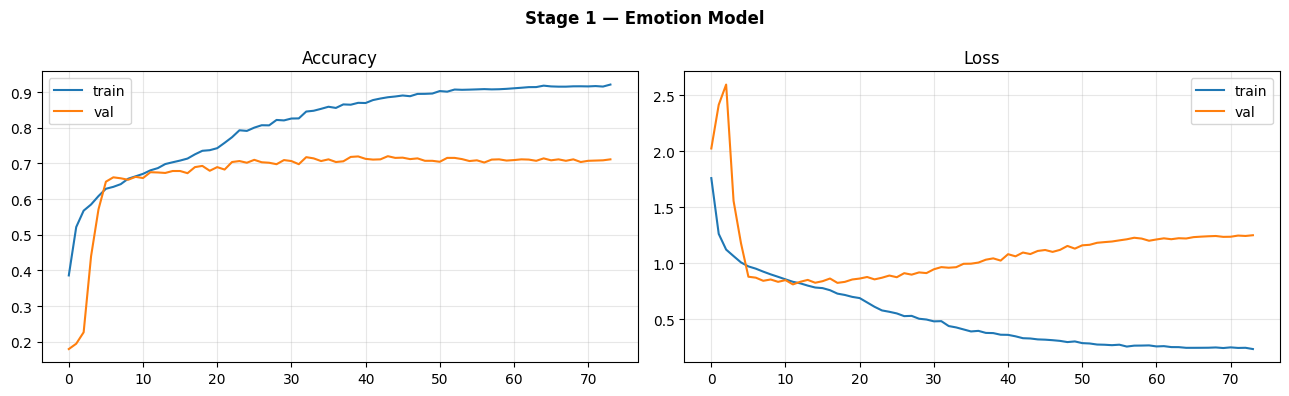

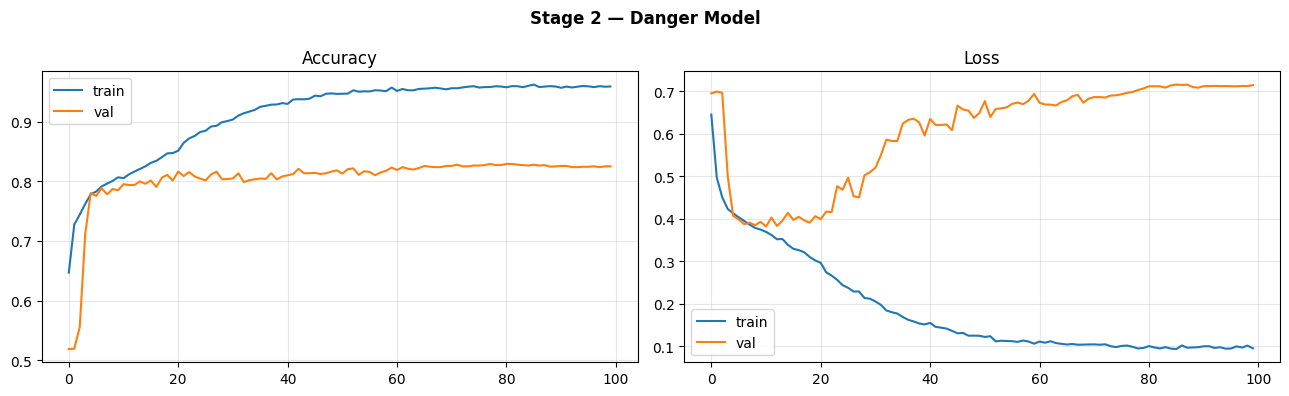

In [ ]:
def plot_history(h, title):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontweight='bold')
    a1.plot(h.history['accuracy'],     label='train')
    a1.plot(h.history['val_accuracy'], label='val')
    a1.set_title('Accuracy'); a1.legend(); a1.grid(alpha=.3)
    a2.plot(h.history['loss'],     label='train')
    a2.plot(h.history['val_loss'], label='val')
    a2.set_title('Loss'); a2.legend(); a2.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_history(hist_em, 'Stage 1 — Emotion Model')
plot_history(hist_dg, 'Stage 2 — Danger Model')


Full evaluation on test set

STAGE 1 — EMOTION MODEL
              precision    recall  f1-score   support

       angry       0.86      0.82      0.84       245
        calm       0.78      0.97      0.87        37
     disgust       0.68      0.60      0.64       227
        fear       0.69      0.62      0.66       245
       happy       0.67      0.74      0.70       245
     neutral       0.67      0.70      0.69       207
         sad       0.69      0.74      0.72       245
   surprised       0.72      0.68      0.70        19

    accuracy                           0.71      1470
   macro avg       0.72      0.74      0.73      1470
weighted avg       0.71      0.71      0.71      1470



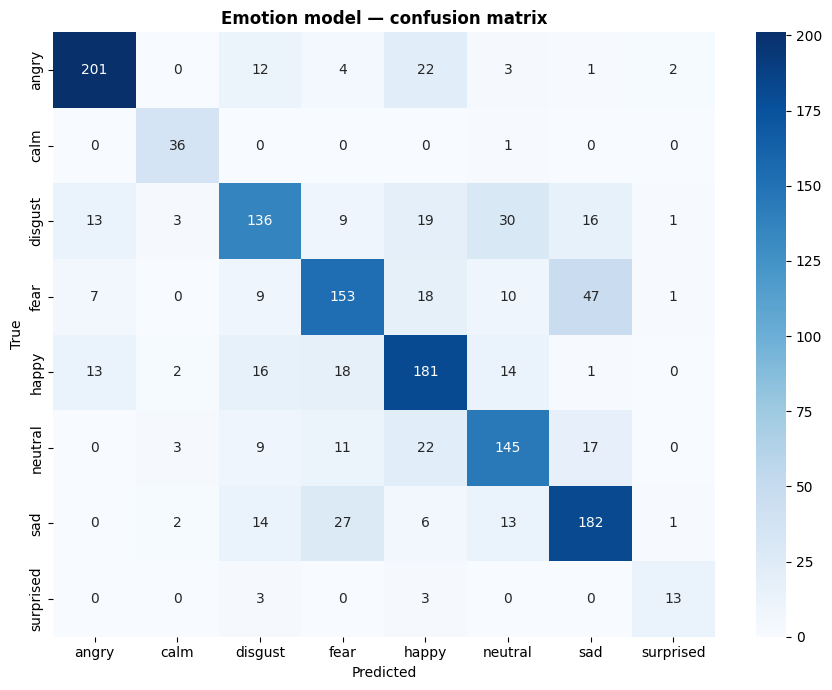


STAGE 2 — DANGER MODEL
              precision    recall  f1-score   support

        CALM       0.81      0.80      0.81       735
      DANGER       0.81      0.81      0.81       735

    accuracy                           0.81      1470
   macro avg       0.81      0.81      0.81      1470
weighted avg       0.81      0.81      0.81      1470



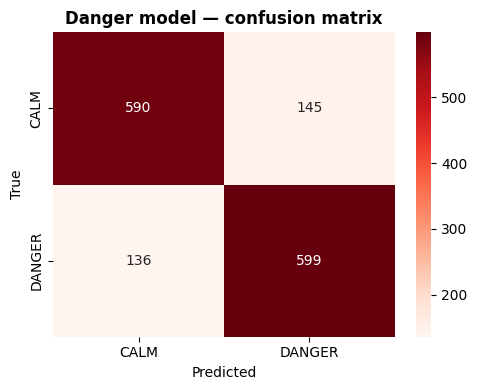

In [ ]:
em_names = list(le_em.classes_)
dg_names = list(le_dg.classes_)

# --- Emotion model ---
print("=" * 55)
print("STAGE 1 — EMOTION MODEL")
print("=" * 55)
yp_em = np.argmax(emotion_model.predict(Xte_em, verbose=0), axis=1)
print(classification_report(yte_em, yp_em, target_names=em_names))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(confusion_matrix(yte_em, yp_em),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=em_names, yticklabels=em_names, ax=ax)
ax.set_title('Emotion model — confusion matrix', fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

# --- Danger model ---
print("\n" + "=" * 55)
print("STAGE 2 — DANGER MODEL")
print("=" * 55)
yp_dg_prob = danger_model.predict(Xte_dg, verbose=0).flatten()
# align probability direction
if DANGER_IDX == 0:
    yp_dg_prob = 1 - yp_dg_prob
yp_dg = (yp_dg_prob >= 0.5).astype(int)
print(classification_report(yte_dg, yp_dg, target_names=dg_names))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(yte_dg, yp_dg),
            annot=True, fmt='d', cmap='Reds',
            xticklabels=dg_names, yticklabels=dg_names, ax=ax)
ax.set_title('Danger model — confusion matrix', fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

VoiceDangerDetector class — two-stage pipeline

In [ ]:
class VoiceDangerDetector:
    """
    Two-stage voice danger detection.
    Stage 1 → emotion (8 classes)
    Stage 2 → DANGER flag (binary)
    """
    def __init__(self, threshold=0.55):
        self.em_model  = emotion_model
        self.dg_model  = danger_model
        self.scaler    = scaler
        self.le_em     = le_em
        self.le_dg     = le_dg
        self.threshold = threshold
        self.DANGER_IDX = DANGER_IDX

    def _prep(self, path):
        # Changed extract() to extract_fast() to match the scaler's input feature count
        f = extract_fast(path, do_augment=False)
        if f is None: return None
        return self.scaler.transform(f.reshape(1,-1))

    def analyse(self, audio_path):
        X_in = self._prep(audio_path)
        if X_in is None:
            return {'status':'ERROR', 'flag':False,
                    'message':'Could not process audio.'}

        # Stage 1 — emotion
        em_probs  = self.em_model.predict(X_in, verbose=0)[0]
        em_idx    = int(np.argmax(em_probs))
        emotion   = self.le_em.classes_[em_idx]
        em_conf   = float(em_probs[em_idx])
        em_all    = {self.le_em.classes_[i]: round(float(em_probs[i]),4)
                     for i in range(len(em_probs))}

        # Stage 2 — danger
        dg_score  = float(self.dg_model.predict(X_in, verbose=0)[0][0])
        if self.DANGER_IDX == 0:
            dg_score = 1.0 - dg_score
        flag      = dg_score >= self.threshold
        status    = 'DANGER' if flag else 'CALM'

        msg = (
            f"{'DANGER FLAG RAISED' if flag else 'ALL CALM'}\n"
            f"  Emotion      : {emotion.upper()}"
            f" ({em_conf*100:.1f}% confident)\n"
            f"  Danger score : {dg_score*100:.1f}%\n"
            f"  Status       : "
            f"{'PERSON MAY BE IN DANGER' if flag else 'No danger detected'}"
        )
        return dict(emotion=emotion, em_conf=em_conf,
                    em_probs=em_all, status=status,
                    danger_score=dg_score, flag=flag, message=msg)

    def show(self, path, result):
        audio, sr = librosa.load(path, sr=SR, duration=DURATION)
        clr = '#E74C3C' if result['flag'] else '#2ECC71'
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(
            f"{'DANGER' if result['flag'] else 'CALM'}"
            f"  |  Emotion: {result['emotion'].upper()}",
            fontweight='bold', color=clr)
        librosa.display.waveshow(audio, sr=sr, ax=a1, color=clr)
        a1.set_title('Waveform')
        probs = result['em_probs']
        bar_colors = ['#E74C3C' if e in DANGER_EMOTIONS
                      else '#2ECC71' for e in probs]
        a2.barh(list(probs.keys()), list(probs.values()),
                color=bar_colors)
        a2.set_xlim(0,1); a2.set_title('Emotion probabilities')
        for i,(e,p) in enumerate(probs.items()):
            a2.text(p+.01, i, f'{p*100:.1f}%', va='center')
        plt.tight_layout(); plt.show()

detector = VoiceDangerDetector()
print("Detector ready!")

Detector ready!


Run inference on real audio files from dataset


True emotion: FEAR  |  True label: DANGER
DANGER FLAG RAISED
  Emotion      : FEAR (100.0% confident)
  Danger score : 99.7%
  Status       : PERSON MAY BE IN DANGER


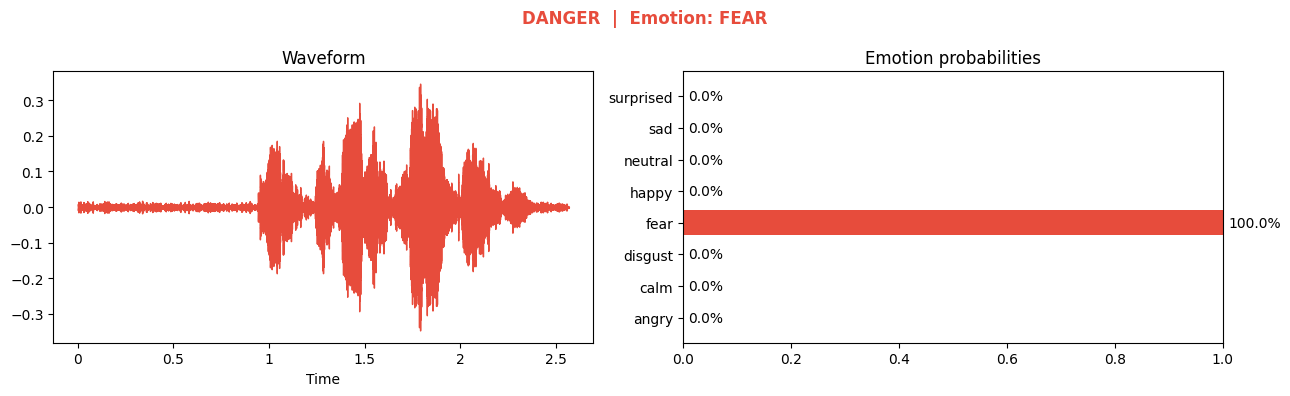

--------------------------------------------------

True emotion: ANGRY  |  True label: DANGER
DANGER FLAG RAISED
  Emotion      : ANGRY (100.0% confident)
  Danger score : 100.0%
  Status       : PERSON MAY BE IN DANGER


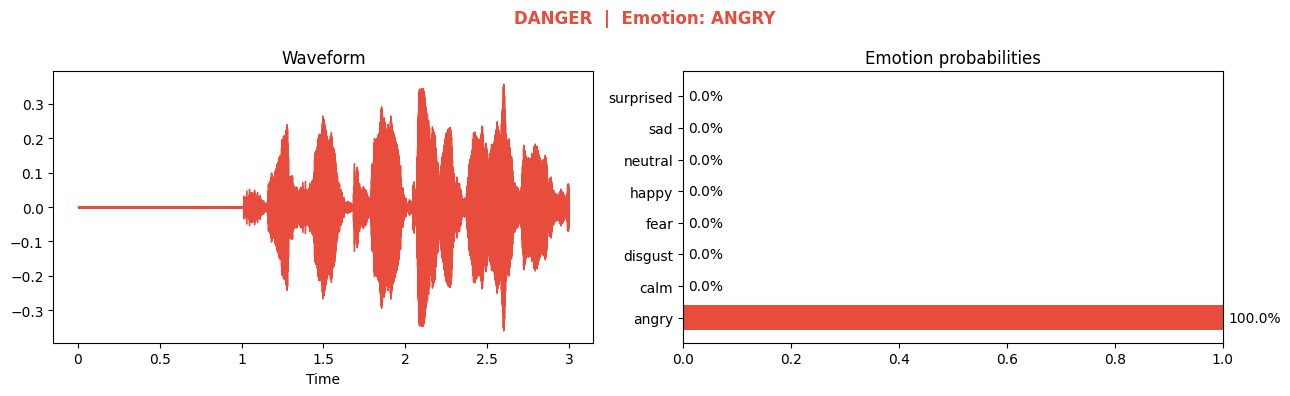

--------------------------------------------------

True emotion: HAPPY  |  True label: CALM
ALL CALM
  Emotion      : HAPPY (100.0% confident)
  Danger score : 0.0%
  Status       : No danger detected


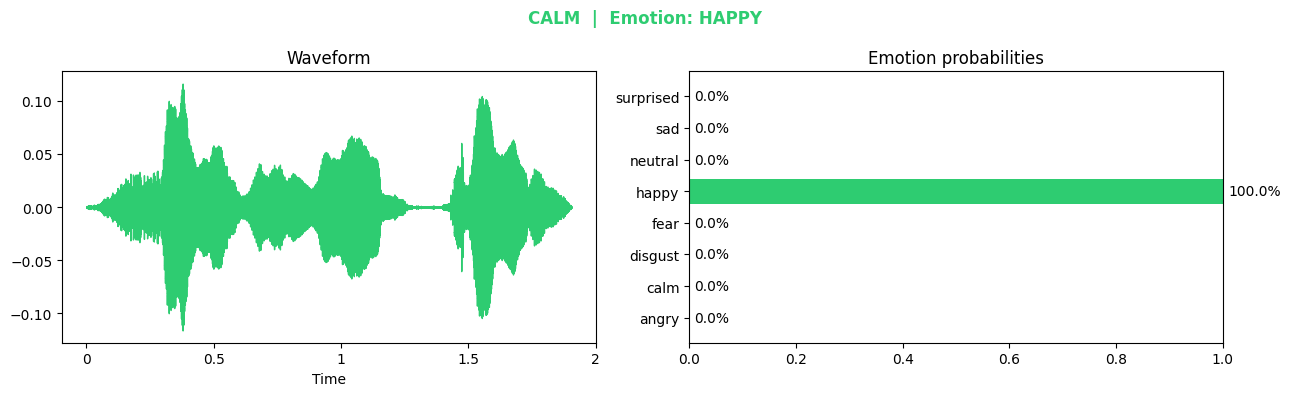

--------------------------------------------------

True emotion: NEUTRAL  |  True label: CALM
ALL CALM
  Emotion      : NEUTRAL (81.0% confident)
  Danger score : 0.9%
  Status       : No danger detected


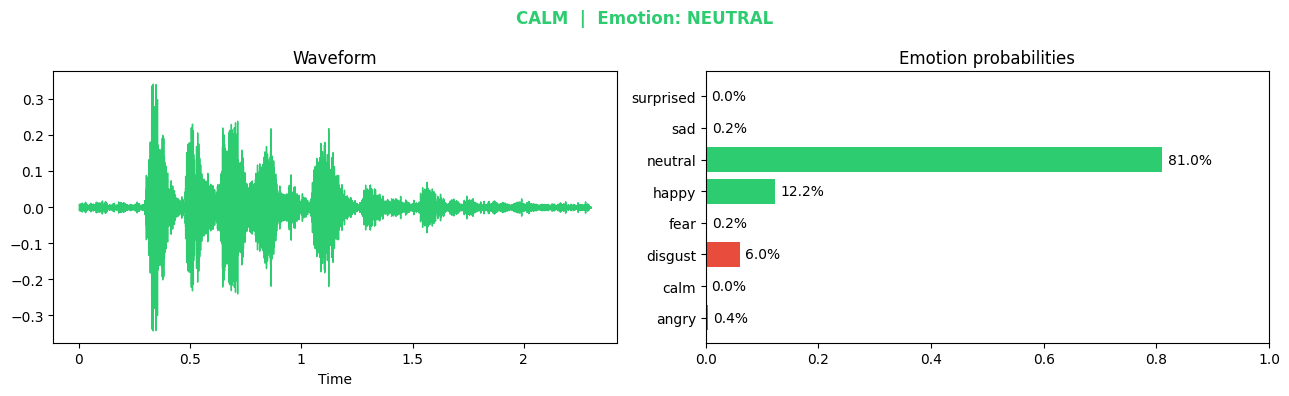

--------------------------------------------------

True emotion: SAD  |  True label: CALM
ALL CALM
  Emotion      : NEUTRAL (50.3% confident)
  Danger score : 20.6%
  Status       : No danger detected


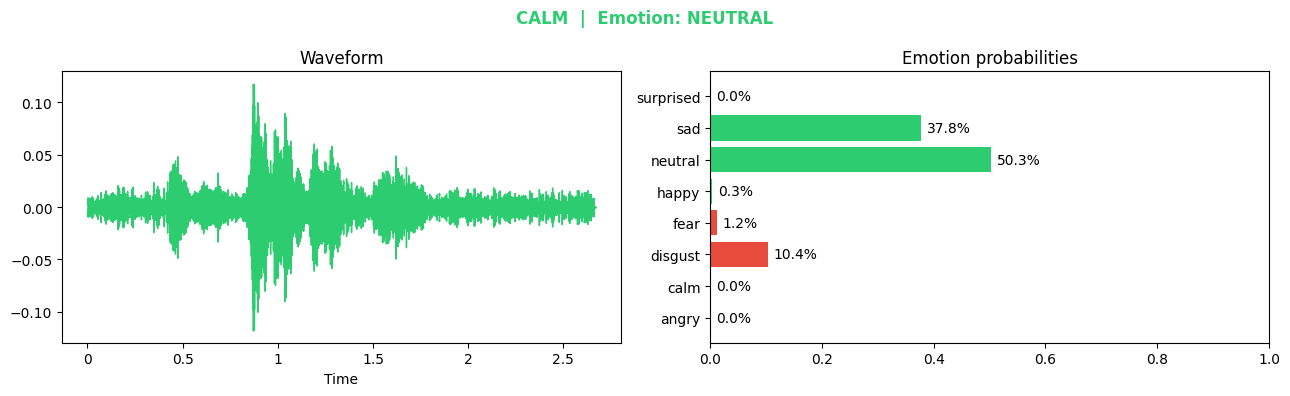

--------------------------------------------------

True emotion: DISGUST  |  True label: DANGER
DANGER FLAG RAISED
  Emotion      : DISGUST (99.4% confident)
  Danger score : 100.0%
  Status       : PERSON MAY BE IN DANGER


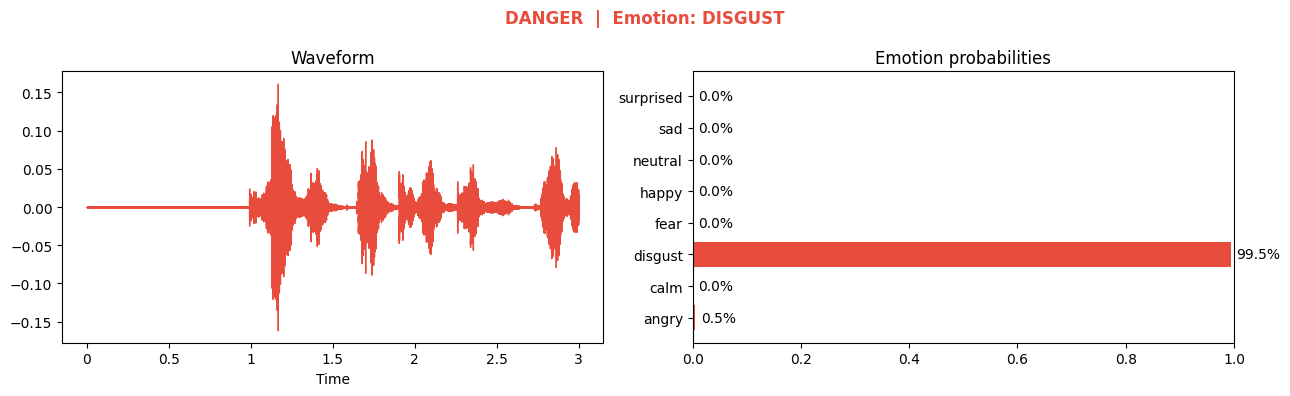

--------------------------------------------------


In [ ]:
test_ems = ['fear', 'angry', 'happy', 'neutral', 'sad', 'disgust']

for em in test_ems:
    sub = df[df['emotion'] == em]
    if len(sub) == 0: continue
    row = sub.sample(1).iloc[0]
    print(f"\nTrue emotion: {row['emotion'].upper()}"
          f"  |  True label: {row['danger']}")
    result = detector.analyse(row['path'])
    print(result['message'])
    display(Audio(row['path']))
    detector.show(row['path'], result)
    print("-" * 50)

Upload any .wav file and detect danger in real time

Upload a .wav file to analyse:


Saving 03-01-05-02-01-01-24.wav to 03-01-05-02-01-01-24.wav

Analysing: 03-01-05-02-01-01-24.wav



DANGER FLAG RAISED
  Emotion      : ANGRY (100.0% confident)
  Danger score : 100.0%
  Status       : PERSON MAY BE IN DANGER

Full emotion breakdown:
  [DANGER] angry        ######################################## 100.0%
  [calm]   calm            0.0%
  [DANGER] disgust         0.0%
  [DANGER] fear            0.0%
  [calm]   happy           0.0%
  [calm]   neutral         0.0%
  [calm]   sad             0.0%
  [DANGER] surprised       0.0%


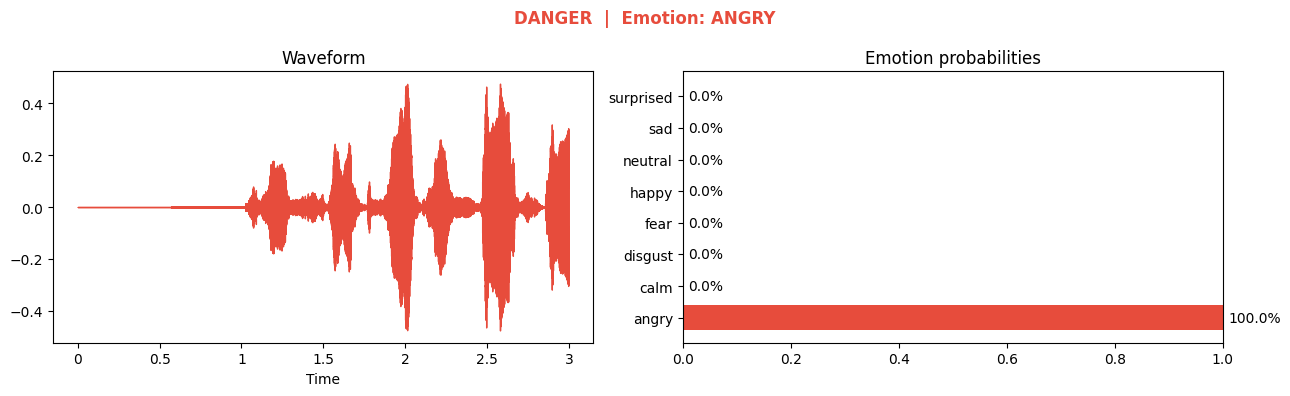

In [ ]:
from google.colab import files

print("Upload a .wav file to analyse:")
uploaded = files.upload()

for fname in uploaded:
    print(f"\nAnalysing: {fname}")
    display(Audio(fname))
    result = detector.analyse(fname)
    print("\n" + "="*50)
    print(result['message'])
    print("="*50)
    print("\nFull emotion breakdown:")
    for em, p in sorted(result['em_probs'].items(),
                        key=lambda x: -x[1]):
        bar = '#' * int(p * 40)
        tag = '[DANGER]' if em in DANGER_EMOTIONS else '[calm]  '
        print(f"  {tag} {em:12s} {bar} {p*100:5.1f}%")
    detector.show(fname, result)

Save trained models and download as zip

In [ ]:

import zipfile
from google.colab import files

emotion_model.save('/content/emotion_model.keras')
danger_model.save( '/content/danger_model.keras')

artifacts = [
    '/content/emotion_model.keras',
    '/content/danger_model.keras',
    '/content/scaler.pkl',
    '/content/le_em.pkl',
    '/content/le_dg.pkl',
]

with zipfile.ZipFile('/content/voice_danger_models.zip','w') as z:
    for a in artifacts:
        if os.path.exists(a):
            z.write(a, os.path.basename(a))
            print(f"  added: {os.path.basename(a)}")

files.download('/content/voice_danger_models.zip')
print("Download started!")



  added: emotion_model.keras
  added: danger_model.keras
  added: scaler.pkl
  added: le_em.pkl
  added: le_dg.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
